# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(100)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
...,...,...,...,...,...,...,...
95,750,159,41,2,2,1,1
96,750,0,50,2,2,1,1
97,750,0,40,1,2,1,1
98,750,0,44,2,1,0,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [ ]:
df.dtypes


,0
Valor_Aluguel,int64
Valor_Condominio,int64
Metragem,int64
N_Quartos,int64
N_banheiros,int64
N_Suites,int64
N_Vagas,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [ ]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


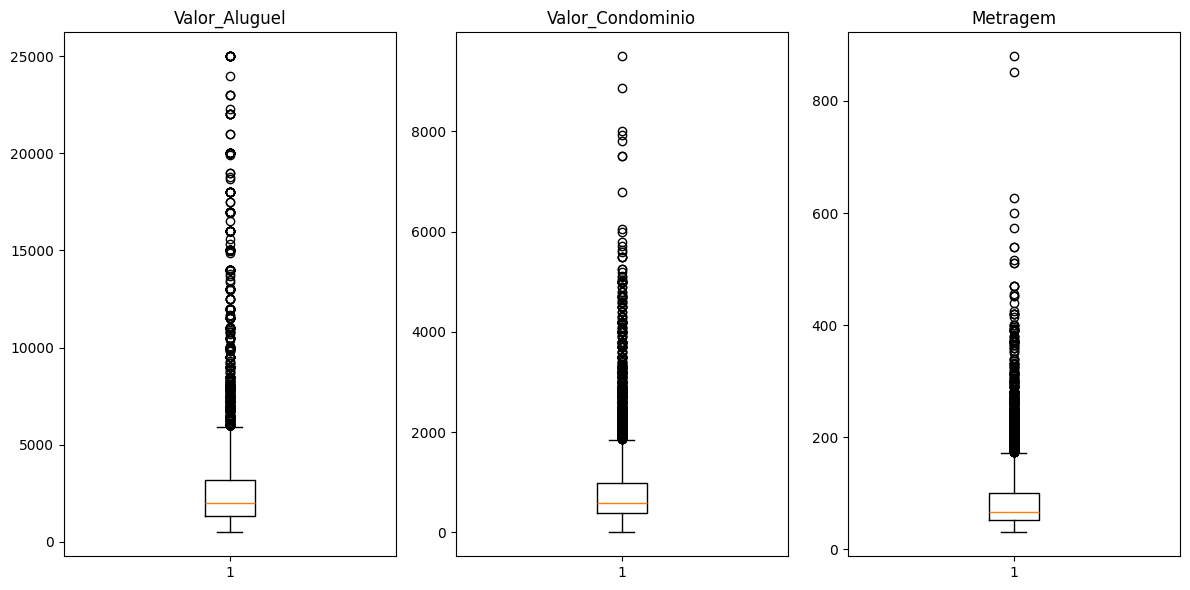

In [ ]:
# Lista das variáveis numéricas principais
variaveis = ['Valor_Aluguel',
              'Valor_Condominio',
              'Metragem']

# Boxplot antes do tratamento
plt.figure(figsize=(12,6))

for i, col in enumerate(variaveis):
    plt.subplot(1,3,i+1)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
for col in variaveis:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= limite_inferior) &
        (df[col] <= limite_superior)
    ]

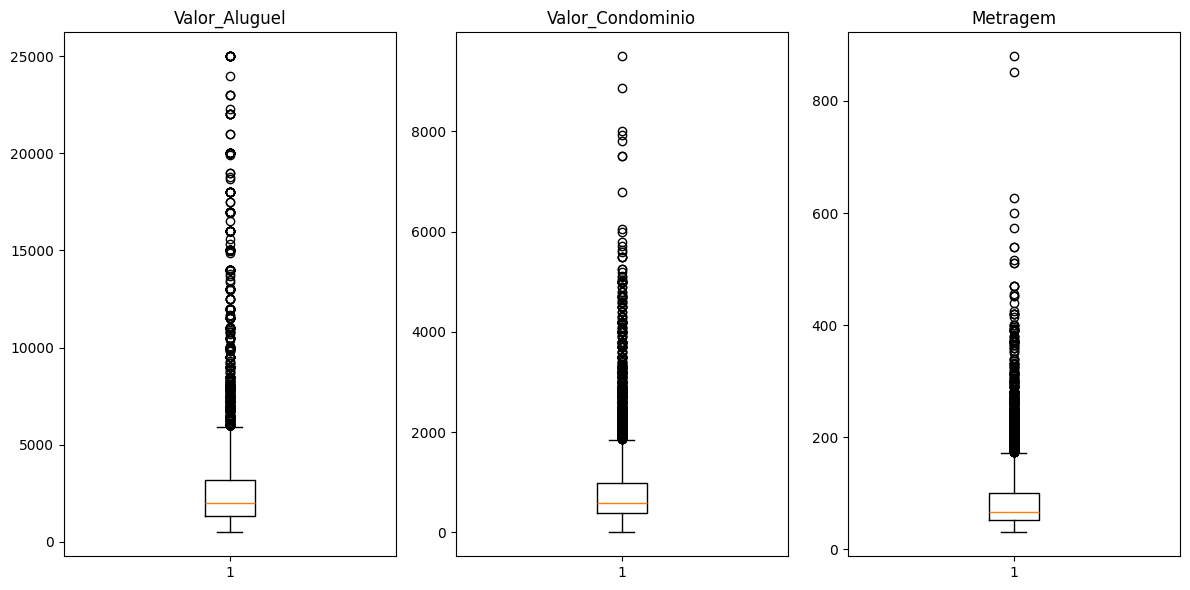

In [ ]:
# Lista das variáveis numéricas principais
variaveis = ['Valor_Aluguel',
              'Valor_Condominio',
              'Metragem']

# Boxplot antes do tratamento
plt.figure(figsize=(12,6))

for i, col in enumerate(variaveis):
    plt.subplot(1,3,i+1)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

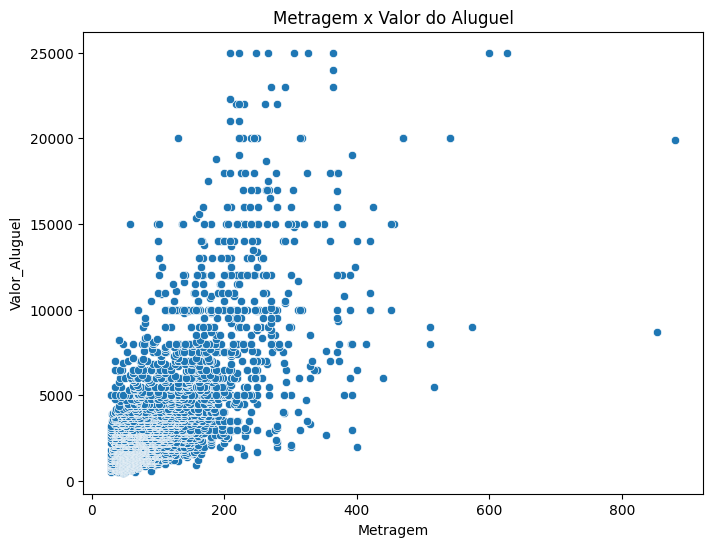

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Metragem',
    y='Valor_Aluguel',
    data=df
)

plt.title('Metragem x Valor do Aluguel')

plt.show()

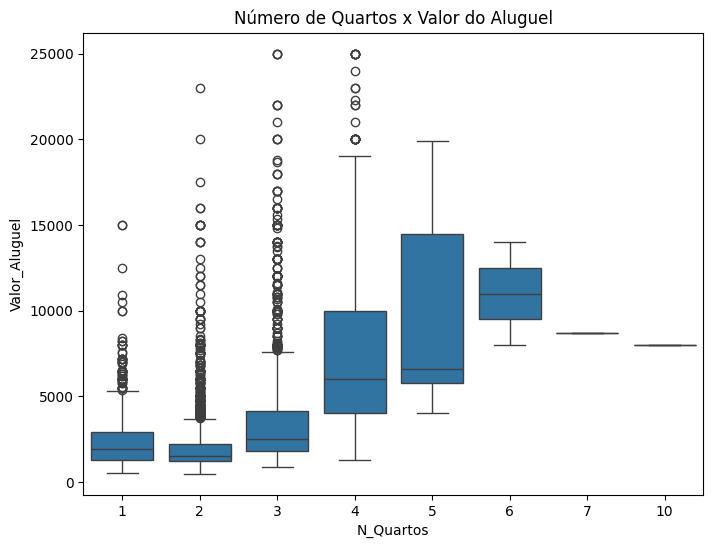

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='N_Quartos',
    y='Valor_Aluguel',
    data=df
)

plt.title('Número de Quartos x Valor do Aluguel')

plt.show()

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




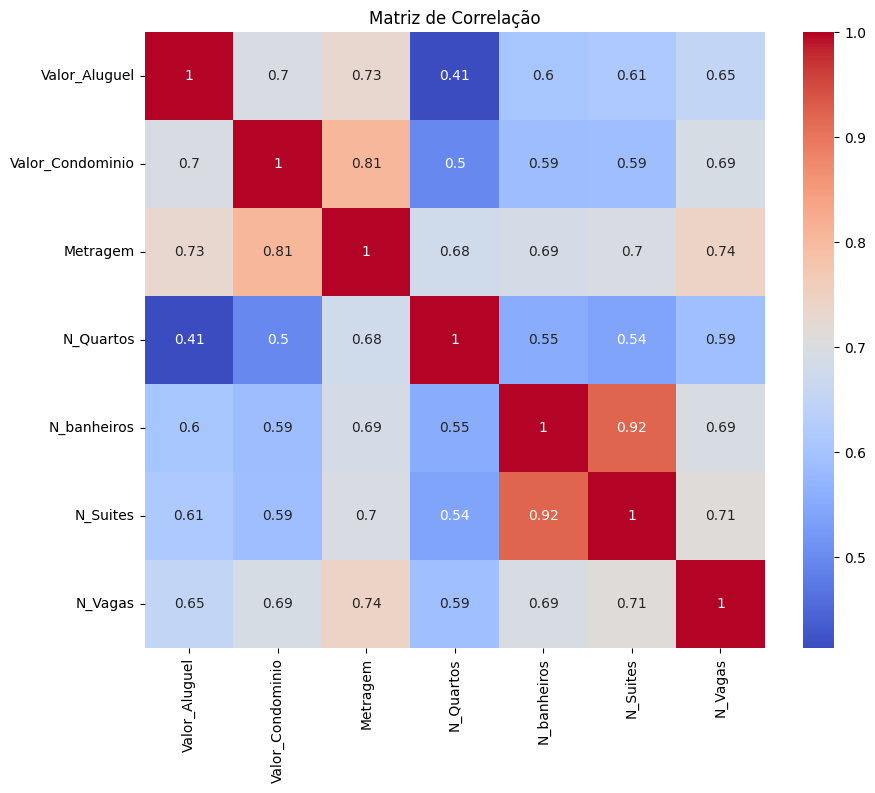

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Matriz de Correlação')

plt.show()


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [ ]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [ ]:
from sklearn.model_selection import train_test_split

# Separando variáveis independentes (X) e dependente (y)
X = df.drop('Valor_Aluguel', axis=1)
y = df['Valor_Aluguel']

# Separando treino e teste (80% treino / 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Verificando tamanhos
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5762, 6)
X_test: (1441, 6)
y_train: (5762,)
y_test: (1441,)


# 4 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [ ]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [ ]:
from sklearn.linear_model import LinearRegression

# Criando o modelo de Regressão Linear
modelo = LinearRegression()

# Treinando o modelo com os dados de treino
modelo.fit(X, y)

# Exibindo coeficiente e intercepto
print("Coeficiente (inclinação):", modelo.coef_)
print("Intercepto:", modelo.intercept_)

Coeficiente (inclinação): [34.47397089]
Intercepto: -96.99896039931718


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

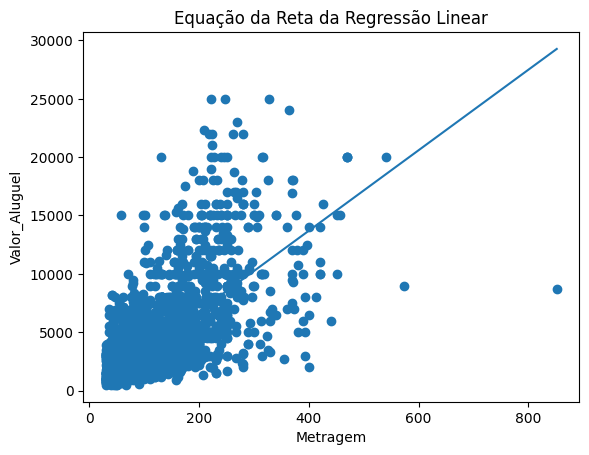

Equação da reta:
Valor_Aluguel = 34.47 * Metragem + (-97.00)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pegando coeficiente e intercepto
coeficiente = modelo.coef_[0]
intercepto = modelo.intercept_

# Criando valores ordenados para a reta
X_vals = np.linspace(X.min(), X.max(), 100)
y_vals = coeficiente * X_vals + intercepto

# Plotando pontos e reta
plt.figure()

plt.scatter(X, y)
plt.plot(X_vals, y_vals)

plt.xlabel("Metragem")
plt.ylabel("Valor_Aluguel")
plt.title("Equação da Reta da Regressão Linear")

plt.show()

# Mostrando equação da reta
print(f"Equação da reta:")
print(f"Valor_Aluguel = {coeficiente:.2f} * Metragem + ({intercepto:.2f})")



Nossa equação seria:  Valor_Aluguel = 34.47 * Metragem + (-97.00)

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [ ]:
from sklearn.metrics import r2_score

# Fazendo previsões com os dados de treino
y_pred_train = modelo.predict(X)

# Calculando R²
r2_treino = r2_score(y, y_pred_train)

print("R² no treino:", r2_treino)

R² no treino: 0.521363231851778


D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

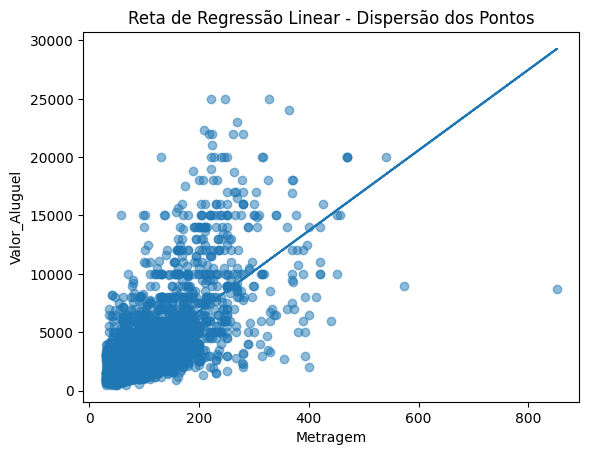

In [ ]:
import matplotlib.pyplot as plt

# Fazendo previsões
y_pred = modelo.predict(X)

# Criando gráfico
plt.figure()

# Pontos reais com transparência (melhora visual)
plt.scatter(X, y, alpha=0.5)

# Linha da regressão
plt.plot(X, y_pred)

plt.xlabel("Metragem")
plt.ylabel("Valor_Aluguel")
plt.title("Reta de Regressão Linear - Dispersão dos Pontos")

plt.show()

## Insights
- Existe relação positiva entre metragem e valor do aluguel.
- Os pontos apresentam dispersão moderada, indicando influência de outras variáveis.
- O R² = 0,52 indica ajuste moderado, sugerindo que um modelo com mais variáveis pode melhorar a previsão.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [ ]:
# Selecionando apenas Metragem sem alterar X_test original
X_test_metragem = X_test[['Metragem']]

# Fazendo previsões
previsoes = modelo.predict(X_test_metragem)

# Calculando R² no teste
r2 = modelo.score(X_test_metragem, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.5697993791211697


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

- Os valores de R² treino (0,52) e teste (0,57) são próximos, indicando boa capacidade de generalização.
- Não há evidência de overfitting, pois o modelo manteve desempenho semelhante em dados novos.
- O modelo apresenta ajuste moderado, sugerindo que a inclusão de mais variáveis pode melhorar a precisão das previsões.

# 5 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [ ]:
# Variáveis independentes (todas exceto Valor_Aluguel)
X = df.drop('Valor_Aluguel', axis=1)

# Variável dependente
y = df['Valor_Aluguel']

# Separação treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Conferindo tamanhos
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (5042, 6)
X_test: (2161, 6)
y_train: (5042,)
y_test: (2161,)


B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [ ]:
modelo = LinearRegression()

modelo.fit(X_train, y_train)

LinearRegression()

C) Traga o valor do R quadrado e avalie o valor encontrado.

In [ ]:
from sklearn.metrics import r2_score

# Previsão na base de treino
y_pred_train = modelo.predict(X_train)

# Cálculo do R² treino
r2_train = r2_score(y_train, y_pred_train)

print("R² treino:", r2_train)

R² treino: 0.5956434956405704


Esse resultado demonstra que o modelo possui desempenho satisfatório, sendo capaz de capturar uma parcela significativa da variação dos dados. No entanto, ainda existe cerca de 40% da variação não explicada, o que sugere que outras variáveis não presentes na base, como localização, bairro ou características adicionais do imóvel, podem influenciar o valor do aluguel. Dessa forma, o modelo apresenta bom desempenho inicial, podendo ser aprimorado com a inclusão de novas variáveis ou ajustes adicionais.

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.




In [ ]:
# Previsão na base de teste
y_pred_test = modelo.predict(X_test)

# Cálculo do R² teste
r2_test = r2_score(y_test, y_pred_test)

print("R² teste:", r2_test)

R² teste: 0.6307353793799015


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

A regressão linear simples e a regressão linear múltipla foram comparadas com o objetivo de avaliar qual modelo apresenta melhor desempenho na previsão do Valor do Aluguel. A regressão linear simples utilizou apenas a variável Metragem como preditora, enquanto a regressão linear múltipla utilizou todas as variáveis disponíveis no conjunto de dados. Observou-se que o modelo de regressão linear múltipla apresentou um valor de R² de teste igual a 0.63, indicando melhor capacidade de explicação da variação do valor do aluguel quando comparado ao modelo de regressão simples. Isso ocorreu porque a regressão múltipla considera simultaneamente diversas características do imóvel, como valor do condomínio, número de vagas, número de banheiros e número de suítes, permitindo capturar melhor os diferentes fatores que influenciam o preço do aluguel. Dessa forma, o modelo de regressão linear múltipla mostrou-se mais eficiente e adequado para prever o valor do aluguel, pois apresentou maior capacidade preditiva e melhor representação da relação entre as variáveis do conjunto de dados.